### Memoria proyecto de Machine Learning

#### Tema: Uso de variables meteorológicas para predecir el costo de la energía




#### 1. Introducción y contextualización del problema

El precio de la energía no es fijo: cambia según hora, ubicación y condiciones del sistema, por lo que es interesante para empresas del sector mejorar la capacidad de anticipación frente a cambios en el precio de la energía, facilitar la planificación operativa y apoyar decisiones que contribuyan a una mayor eficiencia económica.

Este proyecto busca construir de un modelo de aprendizaje automático orientado a estimar la variable objetivo "valor", correspondiente al precio eléctrico marginal por hora. Este modelo se entrena a partir de datos meteorológicos de la subestación electrica Crucero en Chile, y medidas de radiación obtenidas de otra base de datos. Además se busca construir un perfil tipo de precio por hora y por mes de interés para poder anticipar las decisiones de compra y venta de energía.

El conjunto de datos utilizado integra dos fuentes principales. Por una parte, se emplearon registros de precios eléctricos marginales descargados desde Energía Abierta, organizados por mes y por hora.

Por otra parte, se utilizaron datos meteorológicos y deradiación obtenidos desde la National Solar Radiation Database (NSRDB), que aportanvariables explicativas asociadas a temperatura, irradiancia, humedad, presión atmosférica y otras condiciones ambientales.

Desde la perspectiva de negocio, los objetivos perseguidos por el proyecto se relacionan con mejorar la capacidad de anticipación frente a cambios en el precio de la energía, facilitar la planificación operativa y apoyar decisiones que contribuyan a una mayor eficiencia económica.

#### 2. Valor del modelo y aplicaciones prácticas

El principal valor del modelo radica en su capacidad para transformar información meteorológica y temporal en una estimación cuantitativa del precio eléctrico marginal, lo que permite sustituir decisiones reactivas por decisiones más informadas y anticipadas.

Una aplicación práctica directa consiste en el apoyo a la planificación operativa de la empresa Thermophoton. Esta empresa es una startup enfocada en el desarrollo de baterías termofotovoltaicas para almacenar energía proveniente de fuentes renovables. 

El precio de la energía no es fijo: cambia según hora, ubicación y condiciones del sistema, por lo que para ellos es de suma importacia saber además en qué momento es coveniente comprar energía para almacenar y luego en qué momento conviene comprar/vender.

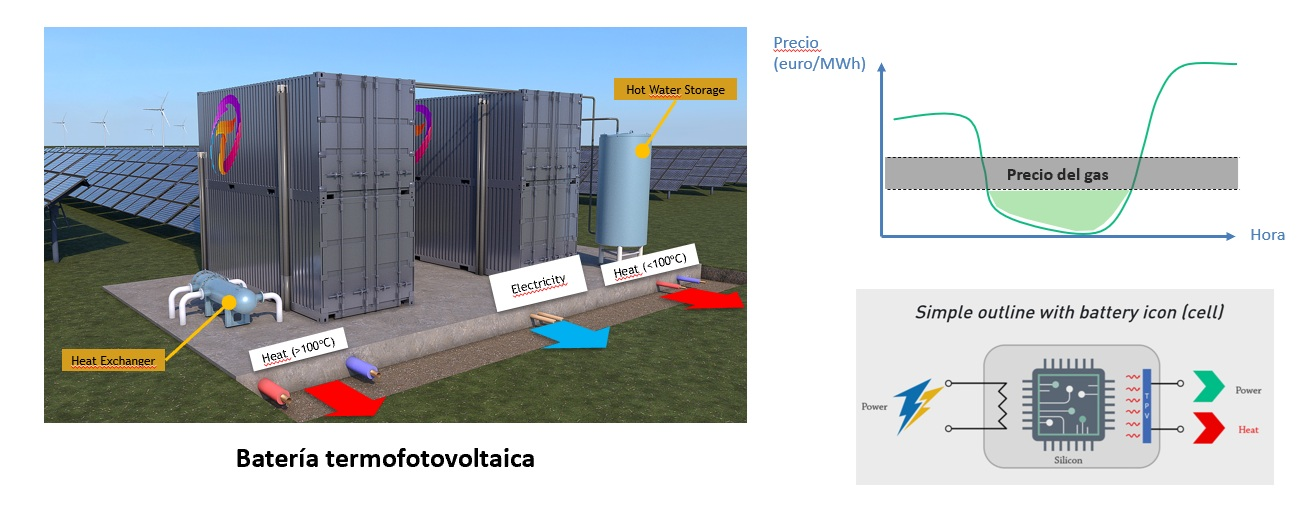

In [7]:
from IPython.display import Image, display

display(Image(filename="../img/Termoph.jpg", width=700))

Imagen 1. Funcionamiento de Termophoton e importancia de la predicción del precio por hora

El precio del gas es fijo como se ve en la gráfica, pero el precio de la electricidad varía según el momento del día. Cuando hay sol a medio día entran a operar las fotovoltaicas y el precio se va a cero, que es el momento óptimo para comprar y almacenar.

#### 3. Metodología y desarrollo del modelo

El desarrollo metodológico se estructuró en tres etapas principales: integración de fuentes, limpieza y análisis exploratorio de los datos, y entrenamiento de modelos predictivos deregresión.

En primer lugar, se consolidaron los registros mensuales del precio eléctrico marginal desde una fuente de datos en un mismo dataset. Luego se vinculó con el segundo dataset que cotiene la información meteorológica, utilizando las variables temporales comunes (mes, día, hora), lo que permitió construir una base de datos unificada para el modelado.

El dataset final utilizado para modelado contiene 14 variables predictoras, de ellas hay variables temporales, otros índices de radiación y variables atmosféricas: Month, Day, Temperature, Hour,DNI, GHI (variables de radiación) y otras.

En la etapa de entrenamiento se evaluaron diversos algoritmos supervisados: regresiónlineal, Ridge, Lasso, Random Forest, Gradient Boosting y XGBoost. Este enfoque comparativo permitió contrastar modelos lineales y no lineales, con el propósito de identificar cuál de ellos capturaba de mejor manera las relaciones presentes en los datos.

Además, el notebook incorpora procedimientos de validación con train_test_split, pipelinesde preprocesamiento y una búsqueda de hiperparámetros mediante GridSearchCV.

Finalmente se utiliza KMeans para construir un perfil por mes para obtener una curva representativa para cada mes del costo de la electricidad por hora y por mes.

3.1 Extracción de datos 

**Datos de precio - variable objetivo**  
  
Se descargan los precios eléctricos marginales por barra, por hora y por mes para el año 2024 para la barra de Crucero, ubicada en la Región de Atacama en Chile. La barra es una subestación de medición, que recibe electricidad de distintos proveedores. Se obtiene un dataset con lo siguientes valores:

- fecha	  
- anio (año)  
- mes  
- dia  
- hora: tiene valores de 1 a 24 según la hora del día  
- barra: subtestación de estimación  
- tension: voltaje a la que va, no es un valor relevante  
- valor: valor de la electricidad en ese momento  

Se puede observar graficamente que hay momentos que la electricidad vale cero o negativo, ya sea porque hay sol y están operando las renovables y hay más oferta que demanda.  

http://energiaabierta.cl/categorias-estadistica/electricidad/?_sf_s=costo

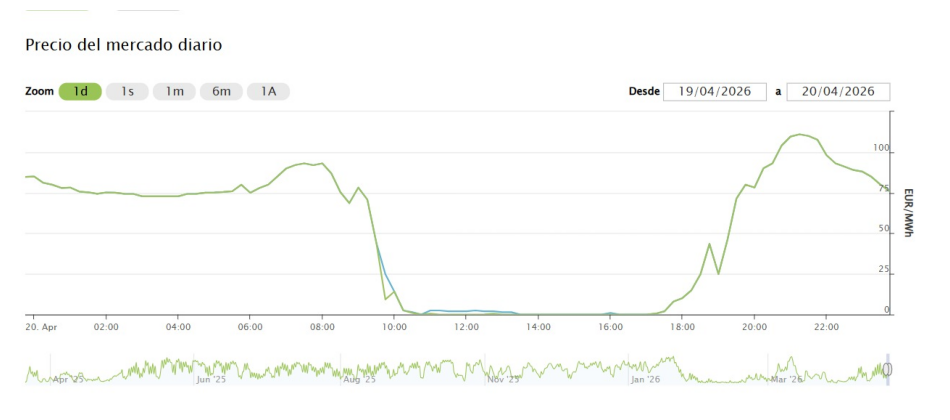

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(r'.\img\Precio_energia_SP.jpeg')
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.show()


**Datos meteorológicos**  

Desde la página National solar radiation data base se obtuvieron datos meteorológicos para el año 2024.

*A. Variables Temporales:*

Year, Month, Day, Hour, Minute: definen el momento exacto del registro de datos.

*B. Variables Meteorológicas y Atmosféricas:*

- Temperature: Temperatura del aire ambiente (normalmente en Celsius).

- Dew Point (Punto de rocío): Temperatura a la que el aire se satura con vapor de agua.

- Relative Humidity: Humedad relativa del aire.

- Pressure: Presión atmosférica local.

- Precipitable Water: Cantidad total de vapor de agua en la columna atmosférica.

- Wind Direction / Wind Speed: Dirección y velocidad del viento.

- Aerosol Optical Depth: Medida de cuánto bloquean los aerosoles (polvo, polución) la luz solar.

- Alpha / SSA: Parámetros ópticos de los aerosoles.

- Asymmetry:  se refiere específicamente al parámetro de asimetría de los aerosoles (Aerosol Asymmetry Parameter).
Es una medida que describe la dirección preferencial en la que los aerosoles (partículas suspendidas en el aire, como polvo, humo o polución) dispersan la luz solar cuando esta choca con ellos


*C. Variables de Irradiancia Solar (Lo más importante para energía solar):*

- GHI (Global Horizontal Irradiance): La suma total de luz solar que llega a una superficie horizontal. Es la variable principal para calcular energía solar.

- DNI (Direct Normal Irradiance): Radiación solar que llega directamente del disco solar sin dispersarse.

- DHI (Diffuse Horizontal Irradiance): Radiación solar que llega dispersada por la atmósfera (nubes, aerosoles).

- Clearsky GHI / DNI / DHI: Valores teóricos de irradiancia en condiciones de cielo perfectamente despejado (sin nubes). Compararlos con los valores reales te permite entender el impacto de las nubes.

- Solar Zenith Angle: Ángulo del sol respecto al cenit; determina la posición del sol en el cielo.


*D. Banderas (Flags) y Otros:*
- Cloud Type: Clasifica el tipo de nubes presentes (ej. cirros, cúmulos).

- Fill Flag: Indica si el dato fue observado o si es una estimación (rellenado) por el modelo porque no había dato real.




3.2. Análisis de las variables:

Se filtraron y reorganizaron las variables para conservar únicamente aquellas con utilidad explicativa real. En el caso del dataset meteorológico, se descartaron columnas técnicas, auxiliares o vacías que no aportaban información al modelo. Tensión por ejemplo tiene un valor constante, así que no interesa para el análisis. 

Se eliminaron otras columnas auxiliares o vacías como Unnamed: 36 hasta Unnamed: 45.

Las variables que se descartaron son: Minute, Alpha, Asymmetry, Clearsky DHI, Clearsky DNI, Clearsky GHI, Cloud Type, Dew Point, Fill Flag, Solar Azimuth Angle,  Wind Speed. En general tenía muchas variables de radiación que eran colineales entre sí y no era conveniente mantener todas en el modelo.

Se redujo el conjunto a 14 variables explicativas más la variable objetivo. Estas son las variables que finalmente se utilizaron:  

Month, Day, Temperature, Hour, Aerosol Optical Depth, Dew Point, DHI, DNI, GHI, Relative Humidity, Solar Zenith Angle, Pressure, Precipitable Water, Wind Direction, valor (Target de precio).

A contuación hay un detalle de todas las variables, su tipo y valor que toma en el dataset:


- Temperatura: Es una variable continua, tiene valores bastante homogéneos, entre 15 y 25 grados celcius, y es normal porque estamos analizando una zona del norte de Chile que no presenta temperaturas extremas.

- Alpha: es un parámetro del modelo atmosférico o de irradiancia usado para describir condiciones de la atmósfera, dispersión o ajuste radiativo. Es una variable continua numérica y tiene valores entre 1.1 y 1.3.

- Aerosol Optical Depth: indica qué tan “turbia” o cargada de aerosoles está la columna de aire; cuanto más alto es el valor, menos transparente está la atmósfera. Es una variable continua numérica y sus valores estàn entre 0.05 y 0.65, pero de acuerdo al boxplot se ven bastantes outliers.

- Asymetry: Está relacionado con el comportamiento óptico de los aerosoles en la atmósfera, al parecer es una variable DISCRETA numérica, y concentrada en pocos valores.  En el histograma se ven como tres “bloques” principales alrededor de 0.62, 0.63 y 0.64, lo que sugiere que Asymmetry toma pocos valores posibles o ha sido redondeada.

- Clearsky DHI: es una medida de radiación, y presenta bastantes outliers, la gran mayoría de las veces vale 0 (cuando no hay sol) y puede legar a valer 350. Esto tiene sentido por las horas de noche, sumado a horas en el día donde no haya sol.

- Clearsky DNI: también es una medida de radiación,por lo que igual a la anterior la gran mayoría de las veces vale 0 (cuando no hay sol) y puede legar a valer 1000. Se observa una distribución con menos outliers que la anterior.

- Clearsky GHI: también es una medida de radiación,por lo que igual a las anteriores la gran mayoría de las veces vale 0 (cuando no hay sol) y puede legar a valer 1200 y la mayoría de los valores se concentran entre 0 y 600.

- Cloud Fill Flag: es una variable discreta categórica, indica si ese valor de nube fue medido directamente, estimado, interpolado o rellenado por el sistema. 0: normalmente significa dato válido o no rellenado. 1: normalmente significa que el dato fue rellenado, corregido o estimado, y puede valer también 7 otro código especial para ellos. En general vale cero y a veces 1 o 7. Es una variable candidata a eliminarse, no parece ser relevante.

- Cloud type: es una variable categórica discreta, y  mide el tipo de nube presente en ese momento, normalmente como una categoría meteorológica. Toma valores entre 0 y 8.

- Dew Point: es una variable numérica continua, y mide la temperatura a la que el aire comienza a saturarse y el vapor de agua se condensa. Suele tomar valores en grados Celsius y y de acuerdo al gráfico entre -25 y 15, los valores se concentran entre 0 y 10 pero tiene algunos outliers negativos.

- DHI: es una variable numérica continua, y mide la radiación solar que llega a una superficie horizontal después de dispersarse en la atmósfera. La mayoría de las veces vale 0 cuando no hay sol hasta 600. Si bien se concentra entre 0 y 100 presenta bastante outliers.

- DNI: es una variable numérica continua, y mide la radiación solar que llega en línea recta desde el sol. Suele tomar valores en W/m².La mayoría de las veces vale 0 cuando no hay sol hasta 1000. 

- Fill Flag: es una variable categórica discreta, y indica si el dato fue rellenado, corregido o estimado por el sistema. Toma tomar valores 0, 1, 5 o 7.

- GHI: es una variable numérica continua, y mide la radiación solar total que recibe una superficie horizontal. Suele tomar valores en W/m² entre 0 y 1200, la mayoría de las veces vale 0 cuando no hay sol y sus valores se concentran entre 0 y 580.

- Ozone: es una variable numérica continua, y mide la cantidad de ozono atmosférico asociada a la columna de aire. Suele tomar valores positivos pequeños, en este caso vale entre 0.2 y 0.3 y tiene una distribución normal. 

- Relative Humidity: es una variable numérica continua, y mide la humedad relativa del aire en porcentaje respecto a la saturación. Tomar valores entre 0 y 100, concentrando sus valores entre 20 y 60.

- Solar Zenith Angle: es una variable numérica continua, y mide el ángulo entre el sol y la vertical local. Toma valores entre 0 y 180 grados.

- SSA: es una variable numérica continua, y mide la fracción de la radiación que se dispersa frente a la que se absorbe. Toma valores entre 0 y 1, pero se concentra entre 0.94 y 0.97 con algunos outliers.

- Surface Albedo: es una variable numérica continua, y mide la fracción de radiación solar que refleja la superficie. Toma valores entre 0.28 y 0.32.

- Pressure: es una variable numérica continua, y mide la presión atmosférica, y los valores se concentran en 878 y 880, con algunos outliers.

- Precipitable Water: es una variable numérica continua, y mide la cantidad de vapor de agua integrado en la columna atmosférica. Toma valores entre 0.2 y 3.7 con algunos outliers.

- Wind Direction: es una variable numérica continua, y mide la dirección desde la que sopla el viento. Tomar valores entre 0 y 360 grados.

- Wind Speed: es una variable numérica continua, y mide la velocidad del viento. Toma valores entre 0 y 7 en m/s.

- valor: es una variable numérica continua, y mide el precio de la electricidad 
usd por mb/h






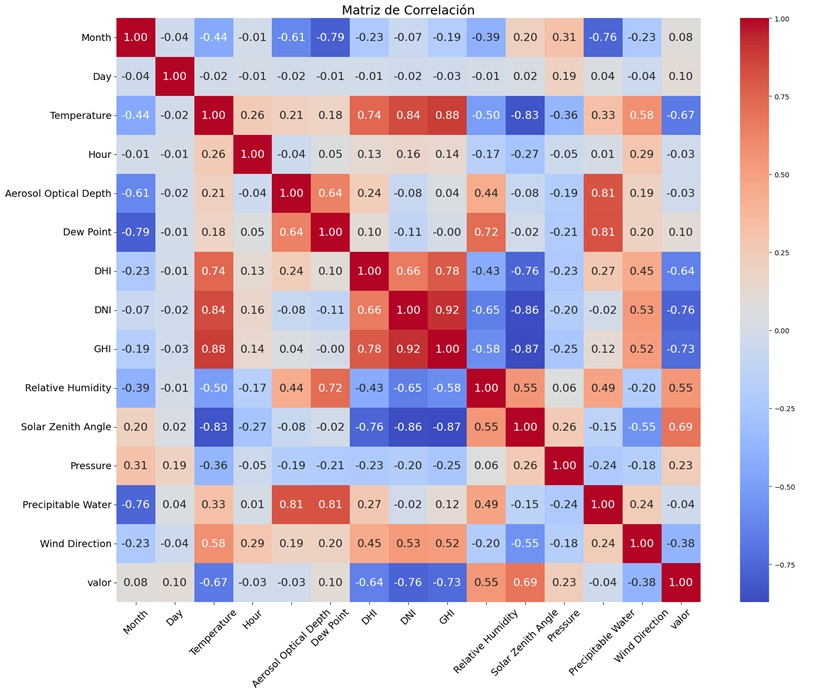

In [8]:
display(Image(filename="../img/Corr.jpg", width=700))

Figura 3: Matriz de correlación entre variables

Como es de esperarse se observa una correlación alta entre las variables de radiación (DHI, DNI, GHI) y valor (Precio de la electricidad).
Temperatura también tiene una correlación interesante.

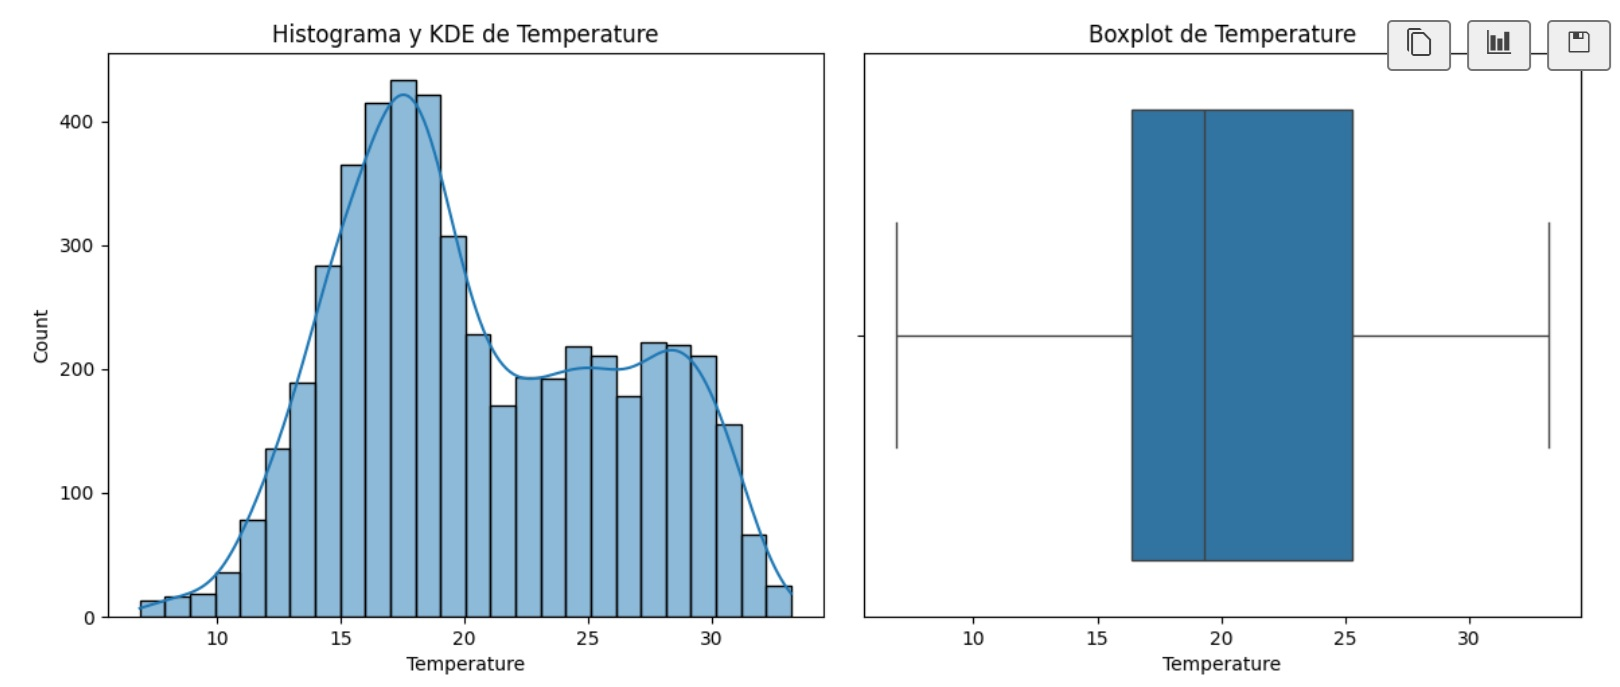

In [ ]:
display(Image(filename="../img/Temperatura.jpg", width=700))

Figura 4: Análisis de la variable temperatura

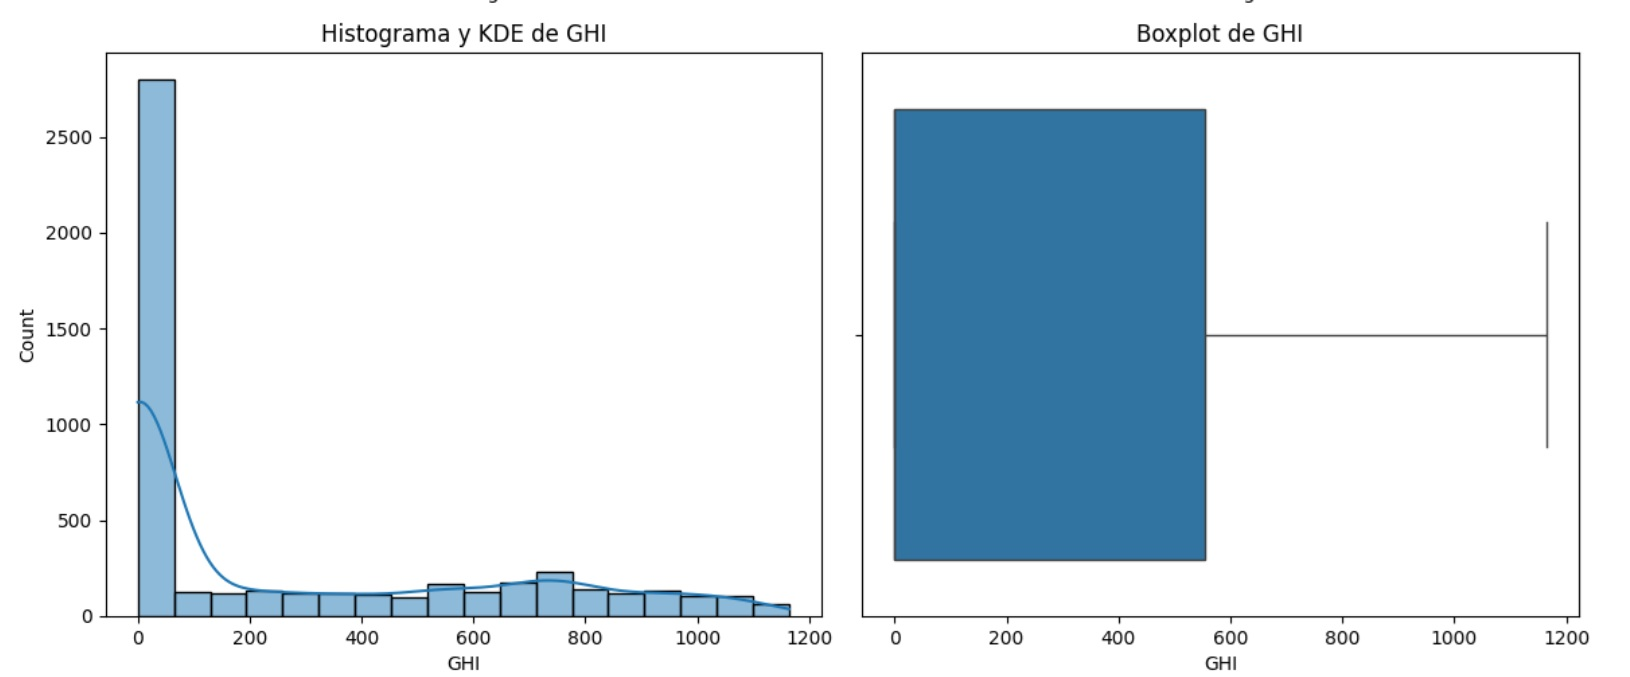

In [ ]:
display(Image(filename="../img/Temperatura.jpg", width=700))

Figura 5: Análisis de la variable GHI de radiación

GHI presenta una distribución asimétrica, con una gran concentración de valores bajos y una cola larga hacia valores altos.  Por la noche o en condiciones muy bajas, GHI cae cerca de cero, y durante las horas centrales aumenta mucho, con valores entre 0 y 1200.

3.3 Modelos utilizados

3.3.1 Modelos Supervisados:   

Se utilizaron los siguientes modelos:


- Linear Regression: modelo lineal que busca la relación promedio entre las variables de entrada y la variable objetivo. Es simple, interpretable y funciona bien cuando la relación es aproximadamente lineal.

- Ridge: es una regresión lineal con regularización L2; penaliza coeficientes grandes para reducir sobreajuste. Suele ir bien cuando hay muchas variables correlacionadas.

- Lasso: también es una regresión lineal con regularización, pero L1; además de reducir coeficientes, puede llevar algunos a cero, actuando como selección de variables.

- Random Forest: combina muchos árboles de decisión entrenados en paralelo y promedia sus resultados. Suele ser robusto y bastante estable, capturando relaciones no lineales.

- Gradient Boosting: construye árboles de forma secuencial, donde cada nuevo árbol corrige errores de los anteriores. Normalmente logra buena precisión, aunque requiere más ajuste de hiperparámetros.

- XGBoost: es una versión optimizada de Gradient Boosting, diseñada para ser más rápida y eficiente. Suele rendir muy bien en datos complejos y no lineales


Se reailzó una prueba con un modelo con 12 variables, y otra prueba con un modelo con 7 variables. Además se trabajaron con dos dataset, uno con el total de 9500 observaciones y luego con la mitad 5000 observaciones. 





3.3.2 Modelos No Supervisados:  

Además del modelado supervisado, se aplicaron técnicas de análisis no supervisado con el objetivo de explorar la estructura interna de los datos y detectar posibles patrones latentes. En particular, se utilizó KMeans para agrupar observaciones con comportamientos similares a partir de las variables meteorológicas y de radiación, lo que permitió identificar perfiles representativos del conjunto de datos sin partir de etiquetas predefinidas.

Para mejorar la interpretabilidad de esta segmentación, se empleó PCA como técnica de reducción de dimensionalidad. Esta metodología permitió proyectar las variables originales en un espacio de menor dimensión, conservando la mayor parte posible de la variabilidad de los datos. De este modo, la visualización de los grupos generados por KMeans resultó más clara y facilitó el análisis de similitudes y diferencias entre observaciones.

Finalmente utilizando KMeans se obtuvo un perfil de precios por hora, para cada mes de la base de datos, que era la información que estaba buscando la empresa de almacenamiento. Para esto fue necesario modificar la estructura del dataset, donde cada fila ahora corresponde a un día, y las columnas son las 24h del día con su precio  (207, 24).

#### 4. Resultados Obtenidos

Los resultados obtenidos muestran diferencias claras entre los modelos evaluados. 

Los modelos lineales, como regresión lineal, Ridge y Lasso, alcanzaron valores de R2 cercanos a 0.66 y errores RMSE en torno a 28.8–28.9, lo que indica una capacidad predictiva moderada.En cambio, los modelos no lineales presentaron un desempeño superior,especialmente Random Forest, que alcanzó un R2 de 0.88.

Gradient Boosting y XGBoost también mostraron resultados competitivos,  R2 de 0.80 y 0.83,respectivamente, aunque por debajo del rendimiento observado en Random Forest. 

En términos interpretativos, esto sugiere que el comportamiento del precio eléctrico marginal no responde únicamente a relaciones lineales simples, sino que depende de interacciones y patrones más complejos entre las variables de entrada.

Bajo esta interpretación, el resultado  del R2 del modelo Random Forest indica unacapacidad predictiva sustancialmente mejor que la de los enfoques lineales, lo que permite afirmar que el objetivo inicial del proyecto se cumple de manera satisfactoria.

Estos resultados se obtuvieron usando las 14 variables y la mitad del dataset (5000 observaciones). Los otros casos evaluados, con menos variables o el dataset completo obtuvieron peores resultados.

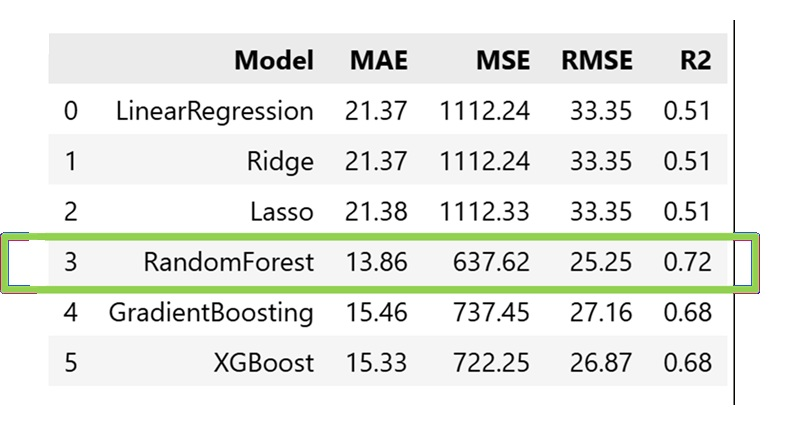

In [22]:
display(Image(filename="../img/Modelos_eval7.jpg", width=400))

Figura 6: Resultado estadístico de los modelos utilizados con 7 variables

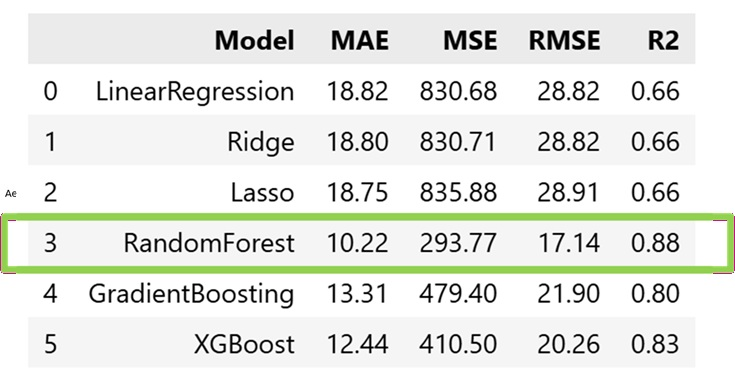

In [23]:
display(Image(filename="../img/Modelos_eval.jpg", width=400))

Figura 7: Resultado estadístico de los modelos utilizados con 14 variables

**Pipeline, validación y selección del modelo**

Para el desarrollo del modelo se construyó un pipeline de aprendizaje supervisado con el objetivo de integrar de forma ordenada el preprocesamiento y el algoritmo predictivo dentro de un mismo flujo de trabajo. Se incorporó escalado de variables dentro del pipeline para asegurar que las magnitudes de entrada no afectaran de forma desproporcionada al ajuste del modelo.

Con el fin de evaluar alternativas con distinto grado de complejidad, se probaron varios modelos: regresión lineal, Ridge, Lasso, Random Forest, Gradient Boosting y XGBoost. 

La selección de hiperparámetros se realizó mediante Grid Search, explorando distintas combinaciones para cada familia de modelos. En particular, se ajustaron parámetros como el nivel de regularización en Ridge y Lasso, así como la profundidad máxima, el número de estimadores y la tasa de aprendizaje en los modelos de ensamblado. Este procedimiento permitió no depender de una única configuración inicial, sino buscar la que ofreciera el mejor equilibrio entre capacidad predictiva y generalización.

Para la validación se empleó cross validation de 5 folds, lo que permitió evaluar el desempeño del modelo de manera más robusta y reducir la dependencia de una única partición train-test. 

Finalmente, el modelo seleccionado fue **XGBBoost con MinMaxScaler**, con mejor desempeño general, con un r2 de 0.88. Este modelo alcanzó un desempeño superior al resto de las alternativas probadas, con un R2 más alto y errores MAE y RMSE más bajos. Por ello, se eligió como modelo final para la memoria, al ser el que mejor capturó la relación entre las variables de entrada y la variable objetivo.

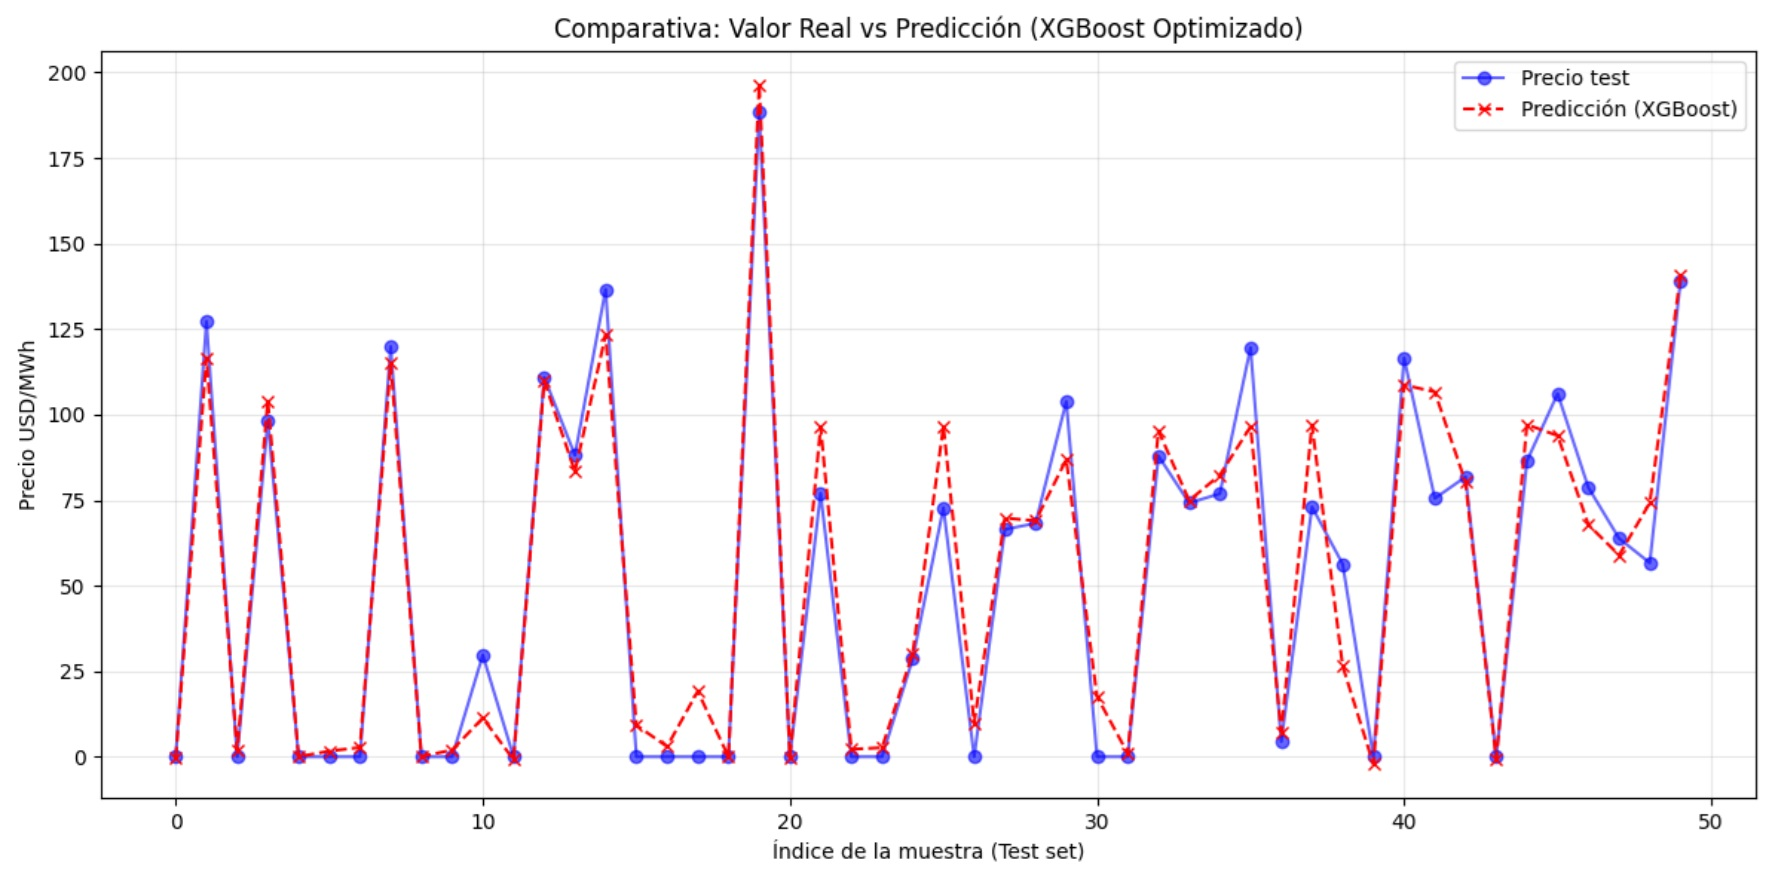

In [28]:
display(Image(filename="../img/Modelo_final.jpg", width=700))

Este gráfico muestra las predicciones en test, para el mejor modelo. Sólo se observan los resultados para las primeras 50 observaciones. 
Visualmente se ve como que el modelo estuviese sobreajustado, pero se están usando los valores del test, por lo que el modelo predice bastante bien el precio para test.

**Resultados del modelo con KMeans**

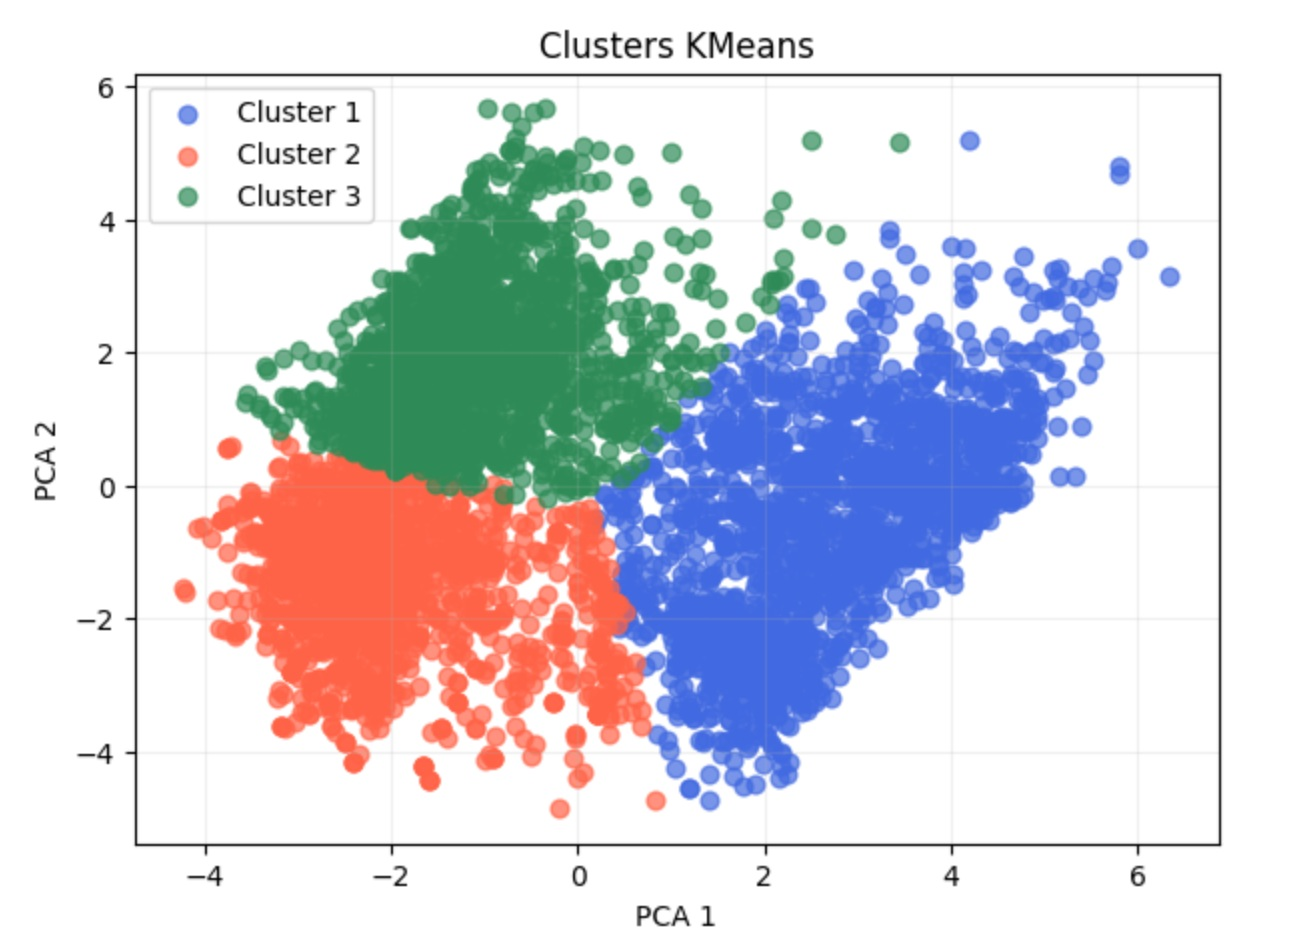

In [19]:
display(Image(filename="../img/PCA.jpg", width=500))

Se observan 3 grupos claramente diferenciados, pero como contienen un porcentaje de cada variable no tiene tanta utilidad práctica como las curvas que se observan a continuación.

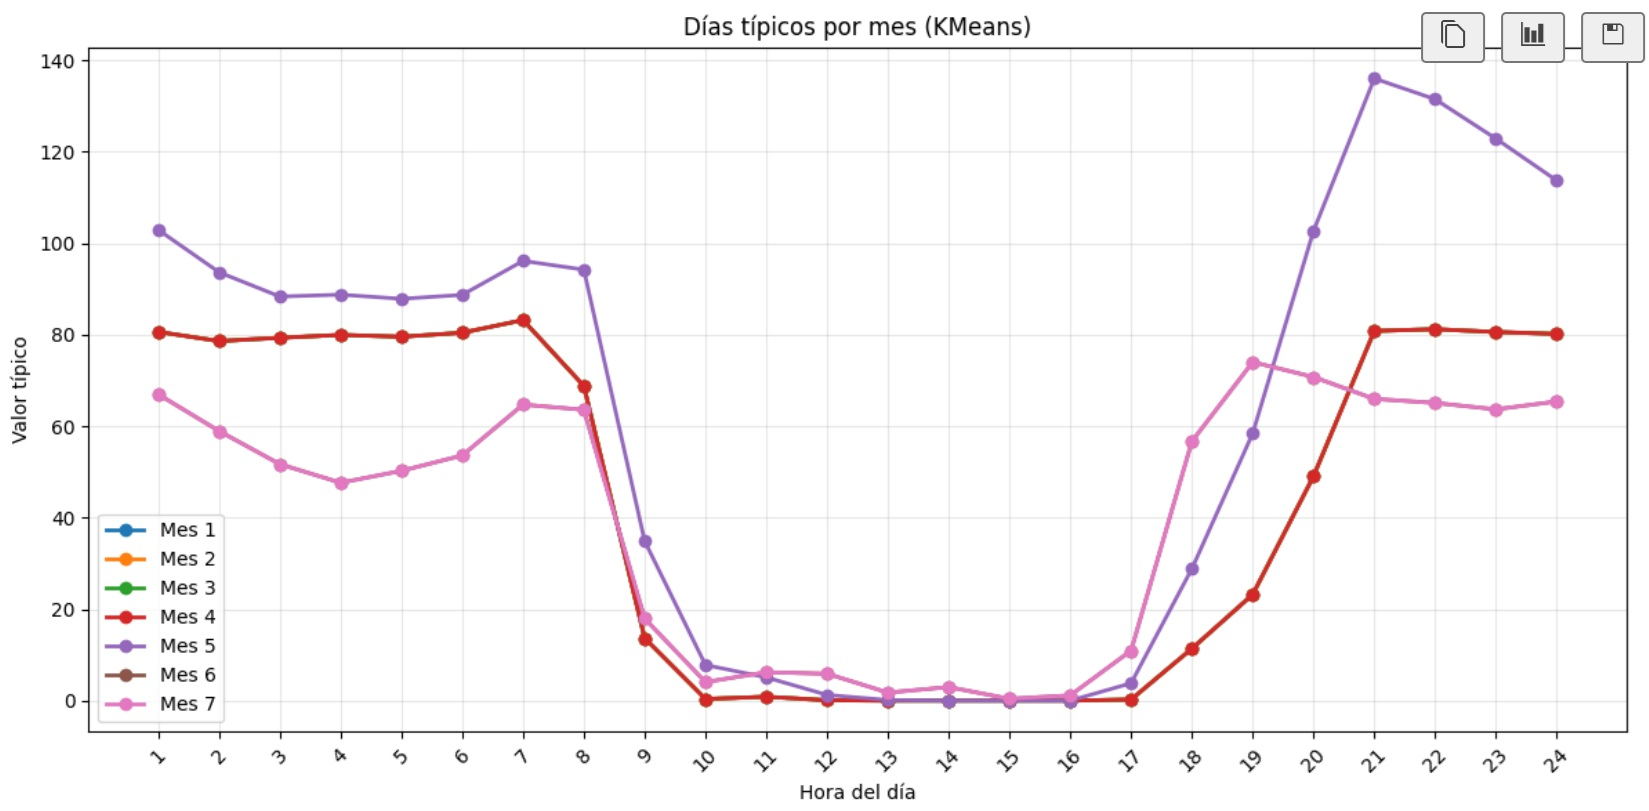

In [18]:
display(Image(filename="../img/Hora_precio.jpg", width=800))

Ahora se define valor de 7 clusters o patrones y se asignas a meses.   
Para cada mes se calcula el cluster que se repite más, y se dibuja una línea por cada mes, basado en su patrón dominante encontrado.   
Esto sí nos permite encontrar claramente en qué momento del día conviene comprar. Para el mes 4 por ejemplo, entre la hora 9 y 18 del día.

#### 5. Conclusiones


El proyecto desarrollado demuestra que es posible construir un modelo predictivo robusto del precio eléctrico marginal a partir de variables meteorológicas y temporales integradasdesde fuentes abiertas.

La metodología aplicada permitió consolidar una base de datos coherente, evaluar distintos algoritmos de regresión y seleccionar unaalternativa con desempeño claramente superior.

Los resultados muestran que los modelos no lineales, y particularmente XGBoost, capturan de mejor manera la complejidad del problema, alcanzando un R2 de 0.88 y un RMSE de 17.14.

Esto confirma que el uso de 14 variables predictoras está metodológicamente justificado y que dicho conjunto de atributos aporta información suficiente y relevante para modelar el comportamiento del precio.

Finalmente se genera una curva tipo mensual que permite predecir en qué momento del día es relevante comprar o vender energía, la cuál ayuda a tomar mejores decisiones económicas.